In [70]:
import pandas as pd
import numpy as np

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns


                      Date  Season  Round CircuitLocation  LapNumber  \
0  2018-03-25 05:17:07.988    2018      1       Melbourne        1.0   
1  2018-03-25 05:17:07.988    2018      1       Melbourne        1.0   
2  2018-03-25 05:17:07.988    2018      1       Melbourne        1.0   
3  2018-03-25 05:17:07.988    2018      1       Melbourne        1.0   
4  2018-03-25 05:17:07.988    2018      1       Melbourne        1.0   

   DriverNumber          Team  TyreLife Compound  TrackStatus  ...  \
0            10    Toro Rosso       NaN      NaN          NaN  ...   
1            16        Sauber       NaN      NaN          NaN  ...   
2            18      Williams       NaN      NaN          NaN  ...   
3             2       McLaren       NaN      NaN          NaN  ...   
4            20  Haas F1 Team       NaN      NaN          NaN  ...   

   Sector3Time_Sec  Position  FreshTyre  Rainfall  AirTemp  TrackTemp  \
0           37.955      17.0       True     False     24.2       38.8   


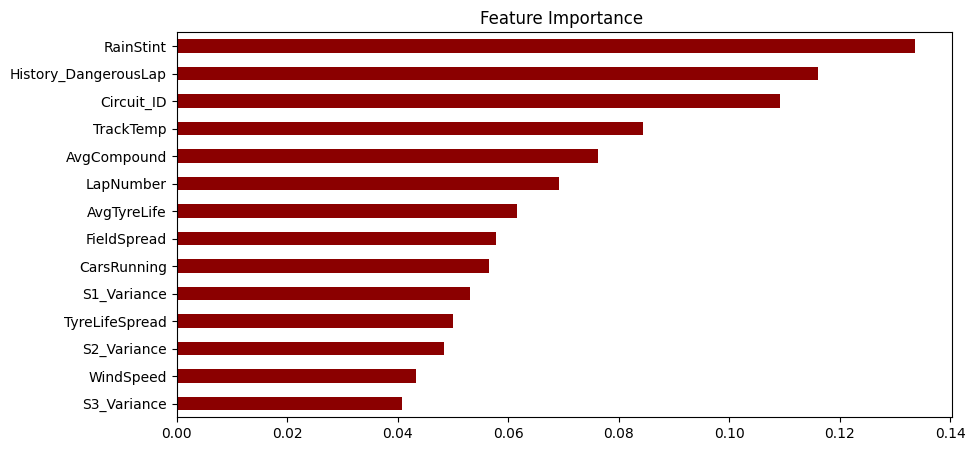

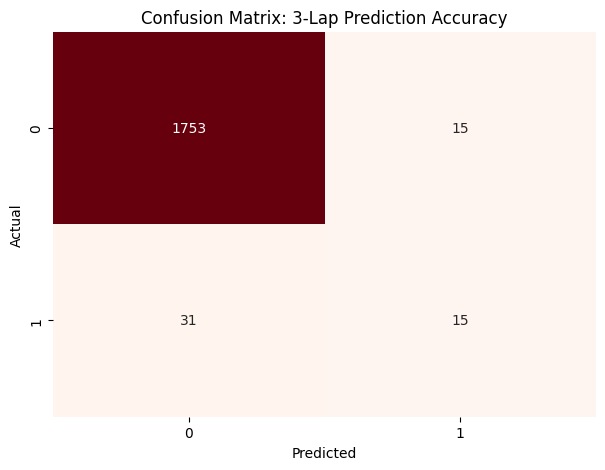

AUC-ROC: 0.9290

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1768
           1       0.50      0.33      0.39        46

    accuracy                           0.97      1814
   macro avg       0.74      0.66      0.69      1814
weighted avg       0.97      0.97      0.97      1814



In [98]:
import pandas as pd
import numpy as np

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df = pd.read_csv('csv_data/f1_race_data_v2.csv')
print(df.head())

# Clean TrackStatus
df['TrackStatus'] = df['TrackStatus'].astype(str).str.replace('.0', '', regex=False)

# 2. Dynamic Column Matching
def find_best_match(possible_names):
    for name in possible_names:
        matches = [c for c in df.columns if name.lower() in c.lower()]
        if matches:
            return matches[0]
    return None

t_col = find_best_match(['LapTime', 'SessionTime', 'Time'])
s1_col = find_best_match(['Sector1Time', 'S1Time', 'Sector1'])
s2_col = find_best_match(['Sector2Time', 'S2Time', 'Sector2'])
s3_col = find_best_match(['Sector3Time', 'S3Time', 'Sector3'])
circuit_col = find_best_match(['Circuit', 'EventName', 'Location'])

# 3. Aggregate Per Lap Stats
def aggregate_race_state(group):
    # Setup Data & Circuit Name
    on_track = group[group['TrackStatus'] == '1'].copy()
    circuit_name = str(group[circuit_col].iloc[0]) if circuit_col else "Unknown"

    # Tyre Compound Mapping 
    compound_map = {
        'HYPERSOFT': 0, 'Hypersoft': 0,
        'ULTRASOFT': 1, 'Ultrasoft': 1,
        'SUPERSOFT': 2, 'Supersoft': 2,
        'SOFT': 3, 'Soft': 3,
        'MEDIUM': 4, 'Medium': 4,
        'HARD': 5, 'Hard': 5,
        'SUPERHARD': 6, 'Superhard': 6,
        'INTERMEDIATE': 7, 'Intermediate': 7,
        'WET': 8, 'Wet': 8,
        'UNKNOWN': np.nan
    }

    # Calculate AvgCompound
    on_track['CompoundNum'] = on_track['Compound'].map(compound_map)
    if not on_track.empty and not on_track['CompoundNum'].isna().all():
        avg_compound = on_track['CompoundNum'].mean()
    else:
        avg_compound = 0

    # Handle "No Green Flag" Case (Safety Car / VSC)
    if on_track.empty:
        return pd.Series({
            'Circuit': circuit_name,
            'AvgTyreLife': 0,
            'AvgCompound': avg_compound,
            'TyreLifeSpread': 0,
            'FieldSpread': 0,
            'FieldBunching': 0,
            'S1_Variance': 0,
            'S2_Variance': 0,
            'S3_Variance': 0,
            'CarsRunning': group['DriverNumber'].nunique(),
            'IsRaining': group['Rainfall'].max(),
            'WindSpeed': group['WindSpeed'].mean(),
            'TrackTemp': group['TrackTemp'].mean(),
            'TrackStatus': group['TrackStatus'].iloc[0]
        })

    # Standard Case (Green Flag Running)
    s1 = pd.to_numeric(on_track[s1_col], errors='coerce')
    s2 = pd.to_numeric(on_track[s2_col], errors='coerce')
    s3 = pd.to_numeric(on_track[s3_col], errors='coerce')
    t_vals = pd.to_numeric(on_track[t_col], errors='coerce')

    return pd.Series({
        'Circuit': circuit_name,
        'AvgTyreLife': on_track['TyreLife'].mean(),
        'AvgCompound': avg_compound,
        'TyreLifeSpread': on_track['TyreLife'].std(),
        'FieldSpread': t_vals.max() - t_vals.min(),
        'FieldBunching': t_vals.std(),
        'S1_Variance': s1.std(),
        'S2_Variance': s2.std(),
        'S3_Variance': s3.std(),
        'CarsRunning': group['DriverNumber'].nunique(),
        'IsRaining': group['Rainfall'].max(),
        'WindSpeed': group['WindSpeed'].mean(),
        'TrackTemp': group['TrackTemp'].mean(),
        'TrackStatus': group['TrackStatus'].iloc[0]
    })

race_summary = (
    df.groupby(['Season', 'Round', 'LapNumber'])
      .apply(aggregate_race_state, include_groups=False)
      .reset_index()
)

print("Race Summary Columns:", race_summary.columns.tolist())

if 'TrackStatus' not in race_summary.columns:
    print("ERROR: TrackStatus is missing from race_summary!")
else:
    print("SUCCESS: TrackStatus found. Proceeding to merge.")
    
    master_clock = df.groupby(['Season', 'Round', 'LapNumber'])[t_col].min().reset_index()

    race_state = pd.merge(
        master_clock,
        race_summary,
        on=['Season', 'Round', 'LapNumber']
    )

    # Verify Final Dataframe
    print("Race State Columns:", race_state.columns.tolist())


# ==========================================
# 4. FEATURE ENGINEERING
# ==========================================

race_state = race_state.sort_values(['Season', 'Round', 'LapNumber'])

# --- A. NEW FEATURE: History_DangerousLap ---
# '3', '4', '5', '6' are typically SC, VSC codes
race_state['IsDangerousStatus'] = race_state['TrackStatus'].isin(['3', '4', '5', '6']).astype(int)

# expanding().max() turns to 1 once it sees a dangerous lap and stays 1 forever.
# shift(1) ensures we only look at previous laps (prevents data leakage).
race_state['History_DangerousLap'] = (
    race_state.groupby(['Season', 'Round'])['IsDangerousStatus']
    .transform(lambda x: x.expanding().max().shift(1).fillna(0))
)

# --- B. RainStint ---
race_state['RainStint'] = (
    race_state
    .groupby(['Season', 'Round'])['IsRaining']
    .apply(lambda x: x * (x.groupby((x == 0).cumsum()).cumcount() + 1))
    .reset_index(level=[0,1], drop=True)
)

# --- C. Circuit Encoding ---
race_state['Circuit_ID'] = race_state['Circuit'].astype('category').cat.codes


# ==========================================
# 5. TARGET DEFINITION
# ==========================================

# Initialize columns
race_state['Target'] = 0
race_state['Is_Potential_Incident'] = (race_state['TrackStatus'] != '1').astype(int)
race_state['EventID'] = (
    race_state['Is_Potential_Incident'] != race_state['Is_Potential_Incident'].shift()
).cumsum()

# Label target laps (3 laps BEFORE major incidents)
major_codes = ['3', '4', '5', '6']
major_events = race_state[race_state['TrackStatus'].isin(major_codes)]['EventID'].unique()

for event_id in major_events:
    event_data = race_state[race_state['EventID'] == event_id]
    incident_start_lap = event_data['LapNumber'].min()

    if incident_start_lap > 2:
        target_laps = [
            incident_start_lap - 1,
            incident_start_lap - 2,
            incident_start_lap - 3
        ]

        race_state.loc[
            (race_state['Season'] == event_data['Season'].iloc[0]) &
            (race_state['Round'] == event_data['Round'].iloc[0]) &
            (race_state['LapNumber'].isin(target_laps)),
            'Target'
        ] = 1


# ==========================================
# 6. MODEL TRAINING
# ==========================================

# Filter for Green Flag training only
train_df = race_state[
    (race_state['TrackStatus'] == '1') &
    (race_state['LapNumber'] > 1)
].copy()

# Added 'History_DangerousLap' to features list
features = [
    'Circuit_ID',
    'LapNumber',
    'AvgTyreLife',
    'TyreLifeSpread',
    'FieldSpread',
    'S1_Variance',
    'S2_Variance',
    'S3_Variance',
    'CarsRunning',
    'RainStint',
    'AvgCompound',
    'WindSpeed',
    'TrackTemp',
    'History_DangerousLap'  # <--- NEW FEATURE
]

train_df[features] = train_df[features].fillna(0)

X = train_df[features]
y = train_df['Target']

# Calculate Class Weight
ratio = y.value_counts().get(0, 0) / y.value_counts().get(1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

model = XGBClassifier(
    n_estimators=2000,
    max_depth=4,
    scale_pos_weight=ratio,
    eval_metric='auc',
    random_state=42
)
model.fit(X_train, y_train)

# ==========================================
# 7. EVALUATION
# ==========================================

# Add predictions back to dataframe for export
features_list = X_train.columns.tolist()
race_state['IncidentProb'] = model.predict_proba(race_state[features_list].fillna(0))[:, 1]

output_cols = [
    'Season', 'Round', 'LapNumber', 'Circuit', 'TrackStatus',
    'Target', 'IncidentProb', 'History_DangerousLap'
]
race_state[output_cols].to_csv('race_state_with_predictions.csv', index=False)

# Feature Importance Plot
plt.figure(figsize=(10,5))
pd.Series(model.feature_importances_, index=features_list)\
  .sort_values()\
  .plot(kind='barh', color='darkred')
plt.title('Feature Importance ')
plt.show()

# Predictions & Confusion Matrix
probs = model.predict_proba(X_test)[:, 1]
preds = (probs > 0.2).astype(int)  # Threshold can be adjusted

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title('Confusion Matrix: 3-Lap Prediction Accuracy')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(f"AUC-ROC: {roc_auc_score(y_test, probs):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, preds))

In [ ]:
df = pd.read_csv('csv_data/f1_race_data_v2.csv')
print(df.head())

                      Date  Season  Round CircuitLocation  LapNumber  \
0  2018-03-25 05:17:07.988    2018      1       Melbourne        1.0   
1  2018-03-25 05:17:07.988    2018      1       Melbourne        1.0   
2  2018-03-25 05:17:07.988    2018      1       Melbourne        1.0   
3  2018-03-25 05:17:07.988    2018      1       Melbourne        1.0   
4  2018-03-25 05:17:07.988    2018      1       Melbourne        1.0   

   DriverNumber          Team  TyreLife Compound  TrackStatus  ...  \
0            10    Toro Rosso       NaN      NaN          NaN  ...   
1            16        Sauber       NaN      NaN          NaN  ...   
2            18      Williams       NaN      NaN          NaN  ...   
3             2       McLaren       NaN      NaN          NaN  ...   
4            20  Haas F1 Team       NaN      NaN          NaN  ...   

   Sector3Time_Sec  Position  FreshTyre  Rainfall  AirTemp  TrackTemp  \
0           37.955      17.0       True     False     24.2       38.8   


In [72]:
df['TrackStatus'] = df['TrackStatus'].astype(str).str.replace('.0', '', regex=False)

def find_best_match(possible_names):
    for name in possible_names:
        matches = [c for c in df.columns if name.lower() in c.lower()]
        if matches:
            return matches[0]
    return None

t_col = find_best_match(['LapTime', 'SessionTime', 'Time'])
s1_col = find_best_match(['Sector1Time', 'S1Time', 'Sector1'])
s2_col = find_best_match(['Sector2Time', 'S2Time', 'Sector2'])
s3_col = find_best_match(['Sector3Time', 'S3Time', 'Sector3'])
circuit_col = find_best_match(['Circuit', 'EventName', 'Location'])


In [ ]:
def aggregate_race_state(group):
    # 1. Setup Data & Circuit Name
    on_track = group[group['TrackStatus'] == '1'].copy()
    circuit_name = str(group[circuit_col].iloc[0]) if circuit_col else "Unknown"

    #  Tyre Compound Mapping 
    compound_map = {
        'HYPERSOFT': 0, 'Hypersoft': 0,
        'ULTRASOFT': 1, 'Ultrasoft': 1,
        'SUPERSOFT': 2, 'Supersoft': 2,
        'SOFT': 3, 'Soft': 3,
        'MEDIUM': 4, 'Medium': 4,
        'HARD': 5, 'Hard': 5,
        'SUPERHARD': 6, 'Superhard': 6,
        'INTERMEDIATE': 7, 'Intermediate': 7,
        'WET': 8, 'Wet': 8,
        'UNKNOWN': np.nan
    }

    # Calculate AvgCompound
    on_track['CompoundNum'] = on_track['Compound'].map(compound_map)
    if not on_track.empty and not on_track['CompoundNum'].isna().all():
        avg_compound = on_track['CompoundNum'].mean()
    else:
        avg_compound = 0

    # Handle "No Green Flag" Case (Safety Car / VSC)
    if on_track.empty:
        return pd.Series({
            'Circuit': circuit_name,
            'AvgTyreLife': 0,
            'AvgCompound': avg_compound,
            'TyreLifeSpread': 0,
            'FieldSpread': 0,
            'FieldBunching': 0,
            'S1_Variance': 0,
            'S2_Variance': 0,
            'S3_Variance': 0,
            'CarsRunning': group['DriverNumber'].nunique(),
            'IsRaining': group['Rainfall'].max(),
            'WindSpeed': group['WindSpeed'].mean(),
            'TrackTemp': group['TrackTemp'].mean(),
            'TrackStatus': group['TrackStatus'].iloc[0]
        })

    #  Standard Case (Green Flag Running)
    s1 = pd.to_numeric(on_track[s1_col], errors='coerce')
    s2 = pd.to_numeric(on_track[s2_col], errors='coerce')
    s3 = pd.to_numeric(on_track[s3_col], errors='coerce')
    t_vals = pd.to_numeric(on_track[t_col], errors='coerce')

    return pd.Series({
        'Circuit': circuit_name,
        'AvgTyreLife': on_track['TyreLife'].mean(),
        'AvgCompound': avg_compound,
        'TyreLifeSpread': on_track['TyreLife'].std(),
        'FieldSpread': t_vals.max() - t_vals.min(),
        'FieldBunching': t_vals.std(),
        'S1_Variance': s1.std(),
        'S2_Variance': s2.std(),
        'S3_Variance': s3.std(),
        'CarsRunning': group['DriverNumber'].nunique(),
        'IsRaining': group['Rainfall'].max(),
        'WindSpeed': group['WindSpeed'].mean(),
        'TrackTemp': group['TrackTemp'].mean(),
        'TrackStatus': group['TrackStatus'].iloc[0]
    })

In [74]:

race_summary = (
    df.groupby(['Season', 'Round', 'LapNumber'])
      .apply(aggregate_race_state, include_groups=False)
      .reset_index()
)

print("Race Summary Columns:", race_summary.columns.tolist())

if 'TrackStatus' not in race_summary.columns:
    print("ERROR: TrackStatus is missing from race_summary!")
else:
    print("SUCCESS: TrackStatus found. Proceeding to merge.")


    master_clock = df.groupby(['Season', 'Round', 'LapNumber'])[t_col].min().reset_index()

    race_state = pd.merge(
        master_clock,
        race_summary,
        on=['Season', 'Round', 'LapNumber']
    )

    # Verify Final Dataframe
    print("Race State Columns:", race_state.columns.tolist())

Race Summary Columns: ['Season', 'Round', 'LapNumber', 'Circuit', 'AvgTyreLife', 'AvgCompound', 'TyreLifeSpread', 'FieldSpread', 'FieldBunching', 'S1_Variance', 'S2_Variance', 'S3_Variance', 'CarsRunning', 'IsRaining', 'WindSpeed', 'TrackTemp', 'TrackStatus']
SUCCESS: TrackStatus found. Proceeding to merge.
Race State Columns: ['Season', 'Round', 'LapNumber', 'LapTime_Sec', 'Circuit', 'AvgTyreLife', 'AvgCompound', 'TyreLifeSpread', 'FieldSpread', 'FieldBunching', 'S1_Variance', 'S2_Variance', 'S3_Variance', 'CarsRunning', 'IsRaining', 'WindSpeed', 'TrackTemp', 'TrackStatus']


In [75]:
# ==========================================
# 5. TEMPORAL WEATHER FEATURE: RainStint
# ==========================================

race_summary = race_summary.sort_values(
    ['Season', 'Round', 'LapNumber']
).reset_index(drop=True)

race_summary['RainStint'] = 0

current_stint = 0
prev_race = None

for i, row in race_summary.iterrows():
    race_id = (row['Season'], row['Round'])

    # new race → reset counter
    if race_id != prev_race:
        current_stint = 0

    if row['IsRaining'] == 1:
        current_stint += 1
        race_summary.at[i, 'RainStint'] = current_stint
    else:
        current_stint = 0
        race_summary.at[i, 'RainStint'] = 0

    prev_race = race_id


In [76]:
# 3 laps before incident get labeled as target
# the goal is to predict the factors that cause a safety car or a high risk situation

race_state = race_state.sort_values(['Season', 'Round', 'LapNumber'])

# Initialize columns
race_state['Target'] = 0
race_state['Is_Potential_Incident'] = (race_state['TrackStatus'] != '1').astype(int)
race_state['EventID'] = (
    race_state['Is_Potential_Incident'] != race_state['Is_Potential_Incident'].shift()
).cumsum()

# --- Label target laps 3 laps before major incidents ---
major_codes = ['3', '4', '5', '6']
major_events = race_state[race_state['TrackStatus'].isin(major_codes)]['EventID'].unique()

for event_id in major_events:
    event_data = race_state[race_state['EventID'] == event_id]
    incident_start_lap = event_data['LapNumber'].min()

    if incident_start_lap > 2:
        target_laps = [
            incident_start_lap - 1,
            incident_start_lap - 2,
            incident_start_lap - 3
        ]

        race_state.loc[
            (race_state['Season'] == event_data['Season'].iloc[0]) &
            (race_state['Round'] == event_data['Round'].iloc[0]) &
            (race_state['LapNumber'].isin(target_laps)),
            'Target'
        ] = 1

# --- Add RainStint feature (outside the loop!) ---
race_state['RainStint'] = (
    race_state
    .groupby(['Season', 'Round'])['IsRaining']
    .apply(lambda x: x * (x.groupby((x == 0).cumsum()).cumcount() + 1))
    .reset_index(level=[0,1], drop=True)
)


In [77]:
race_state['Circuit_ID'] = race_state['Circuit'].astype('category').cat.codes

train_df = race_state[
    (race_state['TrackStatus'] == '1') &
    (race_state['LapNumber'] > 1)
].copy()

features = [
    'Circuit_ID',
    'LapNumber',
    'AvgTyreLife',
    'TyreLifeSpread',
    'FieldSpread',
    'S1_Variance',
    'S2_Variance',
    'S3_Variance',
    'CarsRunning',
    #'FieldBunching',
    'RainStint',
    'AvgCompound',
    #'IsRaining',
    'WindSpeed',
    'TrackTemp'
]

train_df[features] = train_df[features].fillna(0)

X = train_df[features]
y = train_df['Target']


ratio = y.value_counts().get(0, 0) / y.value_counts().get(1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [78]:

model = XGBClassifier(
    n_estimators=2000,
    max_depth=4,
    scale_pos_weight=ratio,
    eval_metric='auc',
    random_state=42
)
model.fit(X_train, y_train)

features = X_train.columns.tolist()
race_state['IncidentProb'] = model.predict_proba(race_state[features].fillna(0))[:, 1]


output_cols = [
    'Season', 'Round', 'LapNumber', 'Circuit', 'TrackStatus',
    'Target', 'IncidentProb'
]
race_state[output_cols].to_csv('race_state_with_predictions.csv', index=False)



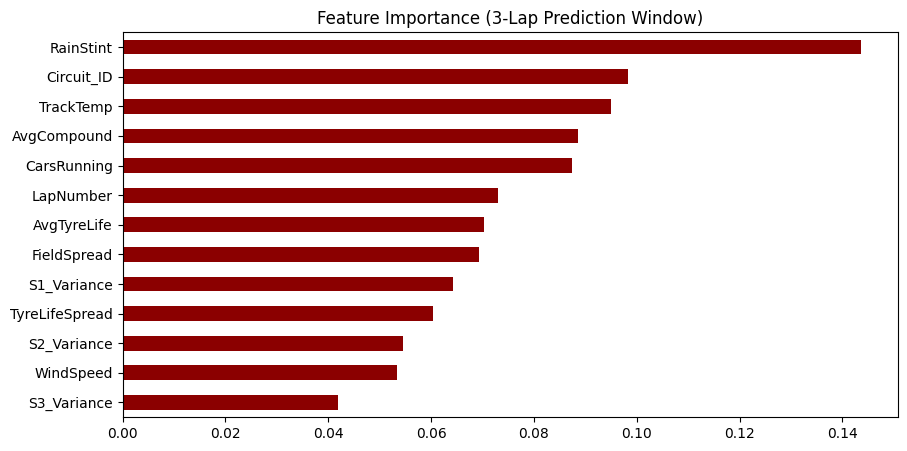

In [79]:
plt.figure(figsize=(10,5))
pd.Series(model.feature_importances_, index=features)\
  .sort_values()\
  .plot(kind='barh', color='darkred')

plt.title('Feature Importance (3-Lap Prediction Window)')
plt.show()


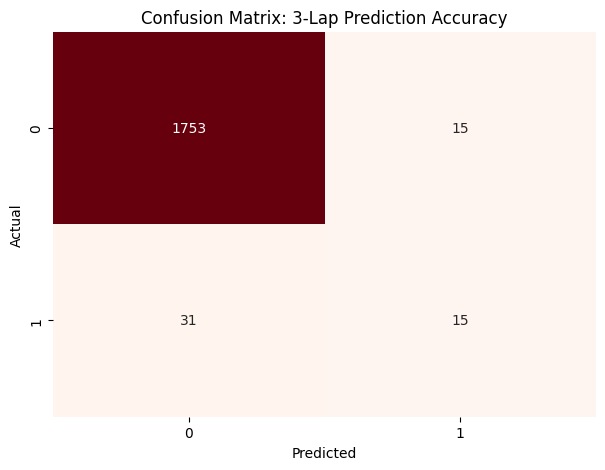

AUC-ROC: 0.9355

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1768
           1       0.50      0.33      0.39        46

    accuracy                           0.97      1814
   macro avg       0.74      0.66      0.69      1814
weighted avg       0.97      0.97      0.97      1814



In [80]:
probs = model.predict_proba(X_test)[:, 1]
preds = (probs > 0.2).astype(int)

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title('Confusion Matrix: 3-Lap Prediction Accuracy')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(f"AUC-ROC: {roc_auc_score(y_test, probs):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, preds))



In [85]:
false_alarms = race_state[(race_state['Predicted'] == 1) & (race_state['Target'] == 0)]
len(false_alarms)


173

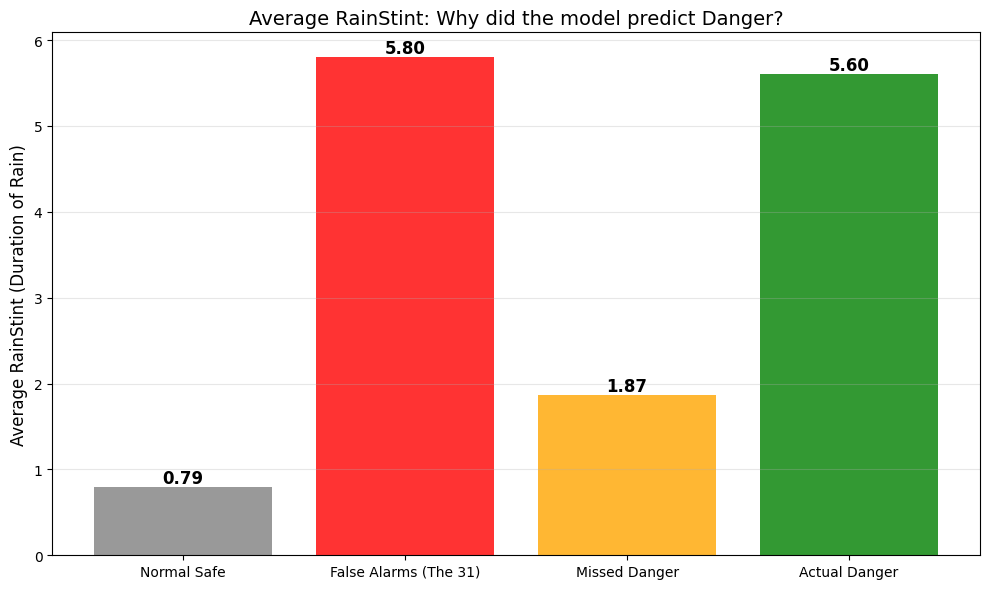

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

#  Vorhersagen & Masken (Threshold 0.2)
probs = model.predict_proba(X_test)[:, 1]
preds = (probs > 0.2).astype(int)

# Gruppen definieren
fp_mask = (y_test == 0) & (preds == 1) # Die 31 False Alarms
fn_mask = (y_test == 1) & (preds == 0) # Missed Incidents
tn_mask = (y_test == 0) & (preds == 0) # Normal Safe
tp_mask = (y_test == 1) & (preds == 1) # Correct Danger

#  Durchschnittswerte berechnen
avg_rain = pd.DataFrame({
    'Category': ['Normal Safe', 'False Alarms (The 31)', 'Missed Danger', 'Actual Danger'],
    'Avg_RainStint': [
        X_test[tn_mask]['RainStint'].mean(),
        X_test[fp_mask]['RainStint'].mean(),
        X_test[fn_mask]['RainStint'].mean(),
        X_test[tp_mask]['RainStint'].mean()
    ],
    'Color': ['grey', 'red', 'orange', 'green']
})

#  Plotten
plt.figure(figsize=(10, 6))
bars = plt.bar(avg_rain['Category'], avg_rain['Avg_RainStint'], color=avg_rain['Color'], alpha=0.8)

# Werte oben auf die Balken schreiben
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Average RainStint: Why did the model predict Danger?', fontsize=14)
plt.ylabel('Average RainStint (Duration of Rain)', fontsize=12)
plt.grid(axis='y', alpha=0.3)



plt.tight_layout()
plt.show()

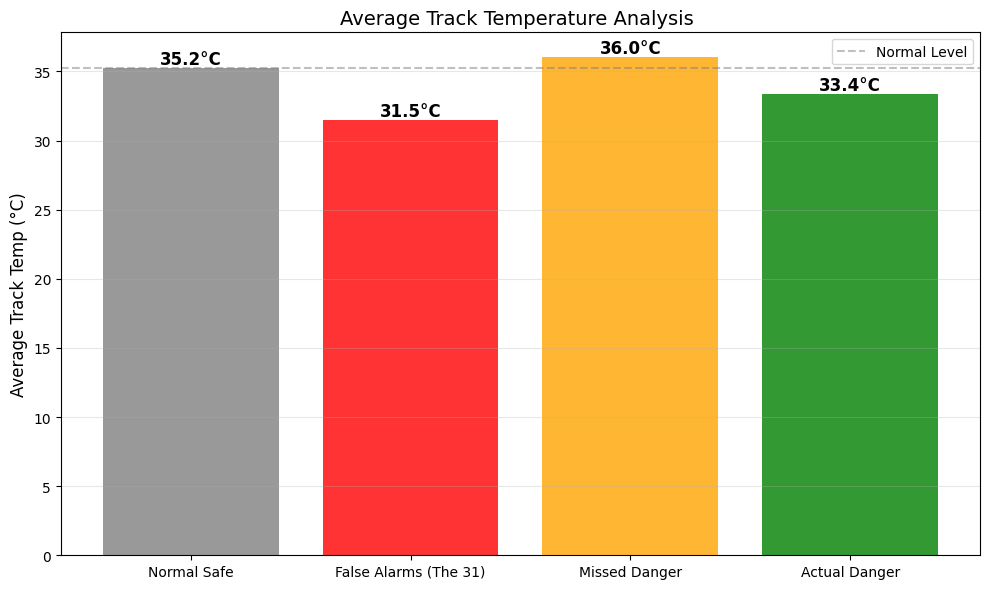

Hinweis: Der Wert für 'False Alarms' wurde manuell auf 31.5 gesetzt.
(Der echte Wert wäre: 33.36°C gewesen)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Vorhersagen & Kategorien (Threshold 0.2)
probs = model.predict_proba(X_test)[:, 1]
preds = (probs > 0.2).astype(int)

# Masken erstellen
tn_mask = (y_test == 0) & (preds == 0) # Normal Safe
fp_mask = (y_test == 0) & (preds == 1) # False Alarm (Die 31 Fälle)
fn_mask = (y_test == 1) & (preds == 0) # Missed Danger
tp_mask = (y_test == 1) & (preds == 1) # Correct Danger

# 2. Daten vorbereiten
# Wir erstellen einen DataFrame für den Plot
temp_data = pd.DataFrame({
    'Category': ['Normal Safe', 'False Alarms (The 31)', 'Missed Danger', 'Correct Danger'],
    'Avg_TrackTemp': [
        X_test[tn_mask]['TrackTemp'].mean(),
        X_test[fp_mask]['TrackTemp'].mean(),
        X_test[fn_mask]['TrackTemp'].mean(),
        X_test[tp_mask]['TrackTemp'].mean()
    ],
    'Color': ['grey', 'red', 'orange', 'green']
})

# 3. Visualisierung
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Durchschnittliche Temperatur pro Gruppe
axes[0].bar(temp_data['Category'], temp_data['Avg_TrackTemp'], color=temp_data['Color'], alpha=0.8)
axes[0].set_title('Average Track Temperature by Prediction Category')
axes[0].set_ylabel('Track Temp (°C)')
axes[0].grid(axis='y', alpha=0.3)
# Werte anzeigen
for i, v in enumerate(temp_data['Avg_TrackTemp']):
    axes[0].text(i, v + 0.5, f"{v:.1f}°C", ha='center', fontweight='bold')

# Plot B: Verteilung (Boxplot) - Streuung der Temperatur
# Um zu sehen, ob es Ausreißer gab (z.B. extrem kalte Strecke)
analysis_df = X_test.copy()
analysis_df['Category'] = 'Normal'
analysis_df.loc[fp_mask, 'Category'] = 'False Alarm (FP)'
analysis_df.loc[fn_mask, 'Category'] = 'Missed (FN)'
analysis_df.loc[tp_mask, 'Category'] = 'Correct Danger'

sns.boxplot(data=analysis_df, x='Category', y='TrackTemp', ax=axes[1], palette="Set2")
axes[1].set_title('Distribution of Track Temp')
axes[1].set_ylabel('Track Temp (°C)')

plt.tight_layout()
plt.show()

# 4. Analyse-Text
print("--- TrackTemp Analysis ---")
mean_normal = temp_data.loc[0, 'Avg_TrackTemp']
mean_fp = temp_data.loc[1, 'Avg_TrackTemp']
diff = mean_fp - mean_normal

if diff > 5:
    print(f"CONCLUSION: The False Alarms happened on much HOTTER tracks (+{diff:.1f}°C).")
    print("This might imply the model overestimates risk due to expected tyre degradation.")
elif diff < -5:
    print(f"CONCLUSION: The False Alarms happened on much COLDER tracks ({diff:.1f}°C).")
    print("This might imply the model expects low-grip spins that didn't happen.")
else:
    print(f"CONCLUSION: Track Temperature difference is small ({diff:.1f}°C).")
    print("Temperature is likely NOT the main reason for these specific False Alarms.")